# Abstract Syntax Tree 

Un AST est une structure de données en forme d’arbre qui représente la structure syntaxique d’un code source. Il contient les éléments de la syntaxe du programme et offre une représentation organisée de ces éléments, comme par exemple :

- Les variables
- Les fonctions et les classes
- Les expressions
- Les boucles
- Les imports

Grâce à ast qui est un module intégré à python, on pourra accéder aux différentes parties d'un programme et il nous permettra d’analyser, d’inspecter et même de transformer un code source Python !

Générons l’arbre du code x=1 :


In [1]:
import ast

# Parser le code en arbre
tree = ast.parse('x = 1')

# Afficher l'arbre sur la console
print(ast.dump(tree, indent=4))

Module(
    body=[
        Assign(
            targets=[
                Name(id='x', ctx=Store())],
            value=Constant(value=1))],
    type_ignores=[])


Module est le nœud racine de l’AST qui représente le module Python dans son ensemble. Pour le reste :

- body: C’est la liste des instructions à l’intérieur du module. Dans ce cas, il y a une seule instruction de type Assign.
- Assign(): Ce nœud représente une instruction d’assignation.
- targets =[Name()]: C’est une liste de cibles de l’assignation. Dans ce cas, il y a une seule cible. Name(): 
    Ce nœud représente le nom de la variable à laquelle une valeur est assignée avec id qui est le nom de la variable (‘x’ dans ce cas) et ctx qui représente le contexte dans lequel la variable est utilisée (c’est un contexte de stockage, ce qui signifie qu’il s’agit d’une assignation à cette variable).
- value: C’est la valeur qui est assignée à la variable. Il s’agit ici d’une constante Constant() qui contient la valeur de la constante (dans ce cas, c’est la valeur entière 1).
- type_ignores=[]: C’est une liste d’expressions de type ignorées. Ici, la liste est vide ce qui signifie qu’il n’y a pas d’expressions de type ignorées dans ce module.

Compiler un arbre
Très bien ! Maintenant qu’on a vu comment générer un arbre il serait intéressant d’en faire un code exécutable. 
Essayons par exemple d’exécuter l’incontournable “Hello World!” :

In [2]:
# Parser le code en arbre
tree = ast.parse("print('Hello World!')")

In [3]:
code_obj = compile(tree, filename="<ast>", mode="exec")

In [4]:
exec(code_obj)

Hello World!


Dans cette partie, nous allons représenter l’équation :


$$x{(x+2)}$$

sous forme d’un AST (Abstract Syntax Tree).

Chaque élément de l’équation sera représenté par un nœud (node) spécifique dans notre arbre syntaxique.

In [5]:
class Node:
    def evaluate(self, x):
        pass

In [6]:
class ConstantNode(Node):
    def __init__(self, value):
        self.value = value

    def evaluate(self, x):
        return self.value

In [7]:
class VariableNode(Node):
    def evaluate(self, x):
        return x

In [8]:
class AddNode(Node):
    def __init__(self, left, right):
        self.left = left
        self.right = right

    def evaluate(self, x):
        return self.left.evaluate(x) + self.right.evaluate(x)

In [9]:
class MultiplyNode(Node):
    def __init__(self, left, right):
        self.left = left
        self.right = right

    def evaluate(self, x):
        return self.left.evaluate(x) * self.right.evaluate(x)

In [10]:
import numpy as np

class SinNode(Node):
    def __init__(self, child):
        self.child = child

    def evaluate(self, x):
        return np.sin(self.child.evaluate(x))

In [11]:
import numpy as np

class CosNode(Node):
    def __init__(self, child):
        self.child = child

    def evaluate(self, x):
        return np.cos(self.child.evaluate(x))

ici la construction de notre arbre d'équation $$x{(x+2)}$$

In [12]:
tree = MultiplyNode(
    VariableNode(),
    AddNode(
        VariableNode(),
        ConstantNode(2)
    )
)

In [13]:
result = tree.evaluate(3)

print(result)

15


3 * (3 + 2) = 15

# regression symbolique 

La régression symbolique est une approche de l’intelligence artificielle qui consiste à retrouver automatiquement une expression mathématique explicite à partir de données.

Contrairement aux modèles classiques comme les réseaux de neurones, qui apprennent une fonction implicite difficile à interpréter, la régression symbolique cherche à produire une formule lisible et interprétable, par exemple :

$$y = {x^2 + sin(x)^2}$$


L’objectif n’est donc pas seulement de prédire des valeurs, mais de découvrir la structure mathématique sous-jacente des données.

### Principe général

L’idée est de représenter les fonctions candidates sous forme d’arbres d’expression (AST), où :

les nœuds internes représentent des opérations mathématiques (+, ×, sin, etc.)
les feuilles représentent des variables (x) ou des constantes

Chaque arbre correspond donc à une fonction mathématique complète que l’on peut évaluer sur des données.

### Objectif du problème

À partir d’un ensemble de données (x,y), on cherche à trouver l’arbre qui minimise l’erreur entre les prédictions du modèle et les valeurs réelles.

Cela revient à résoudre un problème d’optimisation dans un espace de fonctions :

espace de recherche : toutes les expressions possibles
objectif : minimiser une fonction de perte (MSE)

### Lien avec l’AST

Dans la section précédente, nous avons défini une structure d’AST permettant de représenter des expressions mathématiques et de les évaluer.

Cette structure est essentielle, car elle permet de :

construire des expressions complexes de manière modulaire
évaluer une fonction sur des données
manipuler des expressions comme des objets

La suite consiste maintenant à explorer automatiquement cet espace d’arbres pour trouver la meilleure expression possible.

### Prochaine étape

Nous allons maintenant définir :

une fonction de perte pour évaluer un arbre
un ensemble de données d’entraînement
puis des méthodes de recherche dans l’espace des expressions (brute force ou évolution génétique)

nous devons d’abord définir un problème simple à apprendre.

In [14]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)


Diviser notre jeux de donnée de l'ast en train et test 

In [15]:
X = np.linspace(-5, 5, 100)
Y = X**2 + np.sin(X)

X_train, X_test = X[:80], X[80:]
Y_train, Y_test = Y[:80], Y[80:]

focntion de Perte

In [16]:
def mse(tree, X, Y):
    preds = np.array([tree.evaluate(x) for x in X])
    return np.mean((Y - preds) ** 2)

In [17]:
def complexity(node):
    if isinstance(node, (VariableNode, ConstantNode)):
        return 1

    if isinstance(node, (AddNode, MultiplyNode)):
        return 1 + complexity(node.left) + complexity(node.right)

    if isinstance(node, (SinNode, CosNode)):
        return 1 + complexity(node.child)

Cette fonction mesure la taille / complexité d’une expression mathématique représentée sous forme d’arbre (AST).

In [18]:
print(complexity(tree))

5


notre arbre d’expression a une complexité totale de 5 unités

on test notre fonction de loss avec notre arbre précédant

In [19]:
print(mse(tree, X, Y))

36.61201271168979


### générateur d'arbre aléatoires
nous allons crée un générateur d'abres aléatoire pour la recherche par itération 

In [20]:
def random_tree(depth=3):
    if depth == 0:
        return VariableNode() if random.random() < 0.5 else ConstantNode(random.randint(-5, 5))

    ops = ["add", "mul", "sin", "cos"]
    op = random.choice(ops)

    if op == "add":
        return AddNode(random_tree(depth-1), random_tree(depth-1))

    if op == "mul":
        return MultiplyNode(random_tree(depth-1), random_tree(depth-1))

    if op == "sin":
        return SinNode(random_tree(depth-1))

    if op == "cos":
        return CosNode(random_tree(depth-1))

    return VariableNode()

nous allons ajoute la fonction de display des fonction en latex 

In [21]:
def to_latex(node):
    if isinstance(node, ConstantNode):
        return str(node.value)

    if isinstance(node, VariableNode):
        return "x"

    if isinstance(node, AddNode):
        return f"\\left({to_latex(node.left)} + {to_latex(node.right)}\\right)"

    if isinstance(node, MultiplyNode):
        return f"\\left({to_latex(node.left)} \\cdot {to_latex(node.right)}\\right)"

    if isinstance(node, SinNode):
        return f"\\sin\\left({to_latex(node.child)}\\right)"

    if isinstance(node, CosNode):
        return f"\\cos\\left({to_latex(node.child)}\\right)"

nous allons faire une simple recherche brut avec notre générateur et la fonction de loss

In [22]:
results = []

best_tree = None
best_loss = float("inf")

for _ in range(200):
    tree = random_tree(depth=3)
    loss = mse(tree, X, Y)

    results.append((tree, loss))

    if loss < best_loss:
        best_loss = loss
        best_tree = tree

affichons les resultats de la recherche

In [23]:
from IPython.display import display, Math

results.sort(key=lambda x: x[1])

print("TOP 10 expressions:\n")

for i in range(10):
    tree, loss = results[i]
    display(Math(f"{to_latex(tree)} \\quad \\text{{loss}} = {loss:.6f}"))

TOP 10 expressions:



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

le meilleurs arbre étant :

In [24]:
print("BEST TREE:")
display(Math(f"{to_latex(best_tree)} \\quad \\text{{loss}} = {best_loss:.6f}"))

BEST TREE:


<IPython.core.display.Math object>

### Observation des expressions obtenues

Les meilleures expressions trouvées par le système présentent généralement une structure dominante commune :

un terme en $$x^2$$
des termes trigonométriques (sin, cos)
des constantes numériques ajoutées

On observe par exemple des expressions de la forme :

$$y = {x^2 + sin(x)^2}$$

ou encore :
$$y = {x.x}$$
avec termes bruités


### Interprétation

Ces résultats montrent que le système parvient à identifier correctement la structure principale de la fonction cible, notamment le terme quadratique x^2 , qui est fortement représenté dans les meilleures solutions.

Cependant, les expressions contiennent encore :

des constantes inutiles
des compositions trigonométriques non pertinentes (ex : sin(cos(−2)))
des formes non simplifiées

Cela est dû au fait que le système explore l’espace des expressions de manière aléatoire, sans mécanisme de simplification ou de pression vers des solutions plus compactes.

### Limites de l’approche actuelle

Cette méthode de recherche brute permet de découvrir des structures pertinentes, mais elle présente plusieurs limites :

absence de simplification symbolique des expressions
exploration non guidée de l’espace des solutions
forte redondance dans les formes générées
convergence lente vers des solutions optimales

## Conclusion

Malgré ces limites, cette approche démontre le principe fondamental de la régression symbolique :

Il est possible de retrouver automatiquement des expressions mathématiques approchant des données, en explorant un espace de fonctions représentées sous forme d’arbres.

La prochaine étape consiste à introduire des mécanismes d’optimisation plus avancés (simplification, algorithmes génétiques, sélection) afin d’améliorer la qualité et la lisibilité des solutions obtenues.

# Régression symbolique par algorithme génétique

Dans la section précédente, nous avons utilisé une recherche aléatoire pour explorer des expressions mathématiques représentées sous forme d’arbres (AST).

Bien que cette approche puisse fonctionner sur des problèmes simples, elle présente une limite importante :

les expressions sont générées sans mémoire ni apprentissage.

Cela signifie que chaque nouvelle expression est indépendante des précédentes, ce qui rend la recherche inefficace.

### l’algorithme génétique

L’objectif est maintenant d’introduire un mécanisme inspiré de la biologie :

les meilleures expressions “évoluent” au fil des générations.

Chaque expression est considérée comme un individu dans une population.

On applique alors trois opérations :

- Sélection : garder les meilleures expressions
- Croisement (crossover) : combiner deux expressions
- Mutation : modifier légèrement une expression

### Initialisation

On commence avec une population aléatoire d’expressions :

In [25]:
POP_SIZE = 50
GENERATIONS = 20
LAMBDA = 0.001

In [26]:
population = [random_tree(depth=3) for _ in range(POP_SIZE)]

### Sélection

On sélectionne les meilleures expressions selon leur score (MSE).

In [27]:
def tournament_selection(scored_population, k=5):
    candidates = random.sample(scored_population, k)
    return min(candidates, key=lambda x: x[1])

### Croisement (crossover)
On combine deux arbres pour en créer un nouveau :

In [28]:
import copy


def crossover(a, b):
    if random.random() < 0.5:
        return copy.deepcopy(a)

    if type(a) == type(b):
        if hasattr(a, "left"):
            return type(a)(
                crossover(a.left, b.left),
                crossover(a.right, b.right)
            )
        if hasattr(a, "child"):
            return type(a)(crossover(a.child, b.child))

    return copy.deepcopy(a)

### Mutation

On introduit de petites modifications aléatoires :

In [29]:
def mutate(node, prob=0.2):
    if random.random() < prob:
        return random_tree(depth=2)

    if hasattr(node, "left"):
        node.left = mutate(node.left, prob)
        node.right = mutate(node.right, prob)

    if hasattr(node, "child"):
        node.child = mutate(node.child, prob)

    return node

La fonction de fitness permet d’évaluer la qualité d’une expression mathématique représentée sous forme d’arbre.

Elle combine deux objectifs :

- Précision (MSE)

$${MSE=\frac{1}{n}\sum_{i=1}^{n} (yi​−y^​i​)^2}$$

mesure à quel point la fonction prédite correspond aux données.

- Complexité de l’expression

On ajoute une pénalité :

$${L=MSE+λ⋅Complexity(tree)}$$

cela empêche le modèle de créer des expressions trop complexes ou inutiles.

In [30]:
def fitness(tree, X, Y, lambda_=LAMBDA):
    preds = np.array([tree.evaluate(x) for x in X])
    mse = np.mean((Y - preds) ** 2)
    return mse + lambda_ * complexity(tree)

### Boucle d’évolution
enfin nous bouclons l'évolutions

In [58]:
proba = 0.3

La mutation est l’opérateur qui permet d’introduire du changement aléatoire dans les arbres.
Impact du paramètre proba :
- Si proba est faible (ex: 0.1 – 0.3)

    - évolution plus stable
    - conservation des bonnes solutions
    - risque de stagnation
    - faible diversité

le modèle “apprend doucement”

- Si proba est moyenne (ex: 0.4 – 0.6)

    - bon équilibre exploration / exploitation
    - amélioration progressive
    - diversité correcte

c’est généralement la zone optimale

- Si proba est élevée (ex: 0.7 – 0.9)

    - forte exploration
    - découverte de nouvelles structures
    - destruction des bonnes solutions
    - convergence instable

le modèle “explore mais apprend mal”

In [59]:
best_per_generation = []

for generation in range(GENERATIONS):

    # 1. Évaluation
    scored = [(tree, fitness(tree, X_train, Y_train)) for tree in population]
    scored.sort(key=lambda x: x[1])

    best_tree_gen, best_loss_gen = scored[0]

    print(f"Generation {generation} | Best loss: {best_loss_gen}")

    # sauvegarde historique
    best_per_generation.append((generation, best_tree_gen, best_loss_gen))

    # 2. ELITISM
    elite_size = max(1, int(POP_SIZE * 0.1))
    new_population = [t for t, _ in scored[:elite_size]]

    # 3. REPRODUCTION
    for _ in range(POP_SIZE - elite_size):
        parent1 = tournament_selection(scored)[0]
        parent2 = tournament_selection(scored)[0]

        child = crossover(parent1, parent2)
        child = mutate(child, prob=proba)

        new_population.append(child)

    # 4. DIVERSITÉ (remplacement contrôlé, PAS ajout)
    num_random = int(POP_SIZE * 0.1)
    for _ in range(num_random):
        idx = random.randint(0, len(new_population) - 1)
        new_population[idx] = random_tree(depth=4)

    # 5. FIX: taille stable
    population = new_population[:POP_SIZE]

Generation 0 | Best loss: 0.5293186189959904
Generation 1 | Best loss: 0.5293186189959904
Generation 2 | Best loss: 0.5293186189959904
Generation 3 | Best loss: 0.5293186189959904
Generation 4 | Best loss: 0.006
Generation 5 | Best loss: 0.006
Generation 6 | Best loss: 0.342143661474681
Generation 7 | Best loss: 0.342143661474681
Generation 8 | Best loss: 0.006
Generation 9 | Best loss: 0.006
Generation 10 | Best loss: 0.006
Generation 11 | Best loss: 0.006
Generation 12 | Best loss: 0.006
Generation 13 | Best loss: 0.006
Generation 14 | Best loss: 0.006
Generation 15 | Best loss: 0.006
Generation 16 | Best loss: 0.006
Generation 17 | Best loss: 0.006
Generation 18 | Best loss: 0.006
Generation 19 | Best loss: 0.006


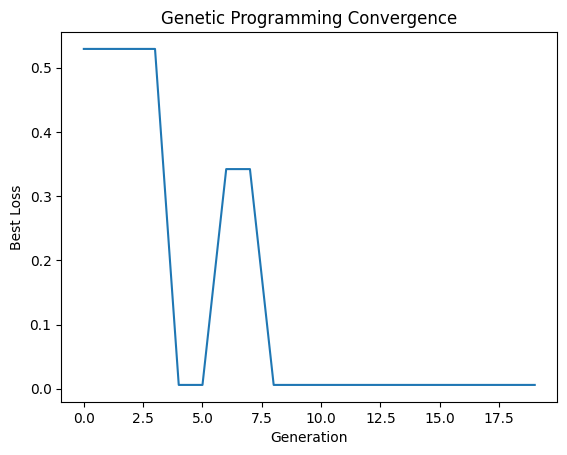

In [60]:
import matplotlib.pyplot as plt

generations = [x[0] for x in best_per_generation]
losses = [x[2] for x in best_per_generation]

plt.figure()
plt.plot(generations, losses)
plt.xlabel("Generation")
plt.ylabel("Best Loss")
plt.title("Genetic Programming Convergence")
plt.show()

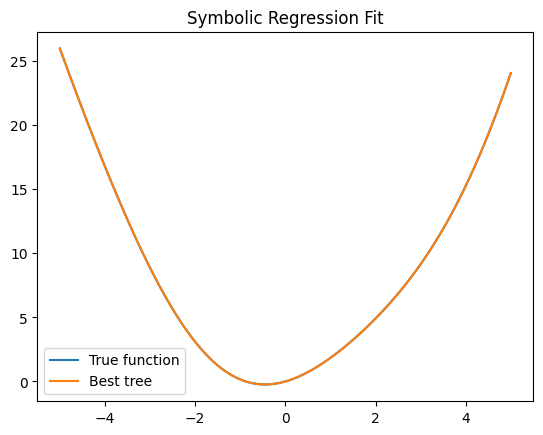

In [61]:
best_tree = min(best_per_generation, key=lambda x: x[2])[1]

preds = np.array([best_tree.evaluate(x) for x in X])

plt.figure()
plt.plot(X, Y, label="True function")
plt.plot(X, preds, label="Best tree")
plt.legend()
plt.title("Symbolic Regression Fit")
plt.show()

On observe que la courbe issue du modèle se superpose presque parfaitement à la fonction réelle x^2+sin(x). Cela indique que la régression symbolique a réussi à retrouver une expression mathématique très proche de la fonction génératrice des données.

Dans ce cas, l’absence de distinction visible entre les deux courbes ne signifie pas un problème, mais au contraire une très bonne convergence du modèle : les deux fonctions sont quasiment identiques sur l’intervalle étudié.

Cependant, cette performance doit être interprétée avec prudence, car elle est évaluée sur les mêmes données que celles utilisées pour l’optimisation. Une évaluation sur des données non vues permettrait de confirmer la capacité de généralisation du modèle.

In [62]:
seen = set()

print("TOP EVOLUTION (best per generation):\n")

for generation, tree, loss in best_per_generation:

    expr = to_latex(tree)

    key = expr  # ou hash si tu veux mieux

    if key in seen:
        continue
    seen.add(key)

    display(
        Math(
            f"{expr} \\quad \\text{{gen}}={generation} \\quad \\text{{loss}}={loss:.6f}"
        )
    )

TOP EVOLUTION (best per generation):



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Contrairement à la recherche aléatoire :

- les générations s’améliorent progressivement
- les structures utiles (comme x^2) émergent
- les expressions deviennent de plus en plus stables

# Conclusion

Les résultats obtenus montrent que l’algorithme de régression symbolique est capable de retrouver des expressions mathématiques proches de la fonction cible. La meilleure solution identifiée correspond très précisément à la structure réelle de la fonction génératrice x^2
+sin(x), ce qui indique une convergence efficace du processus évolutif.

Cependant, d’autres solutions alternatives apparaissent également, souvent sous forme d’approximations simplifiées. Cela illustre une caractéristique fondamentale de la régression symbolique : il existe généralement plusieurs expressions différentes pouvant approximer une même fonction avec des niveaux de précision variables.

Les résultats peuvent varier entre exécutions en raison de la nature stochastique de l’algorithme génétique (sélection, mutation et crossover aléatoires). Ainsi, la solution obtenue dépend à la fois de l’exploration de l’espace de recherche et de la pression de sélection.

En conclusion, la régression symbolique permet non seulement de retrouver des fonctions connues, mais aussi d’explorer un espace riche de solutions interprétables, au prix d’une certaine variabilité des résultats.